In [32]:
# ======================================================
# Core libraries for respiration + social behavior analysis
# ======================================================

# --- Core Python ---
import os
import h5py
import re

# --- Numerical & data analysis ---
import numpy as np
import pandas as pd

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches

# --- Signal processing ---
from scipy.signal import butter, filtfilt, resample_poly, find_peaks

# --- Statistics ---
from scipy.stats import wilcoxon

# --- Machine learning & metrics ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline



# --- Specialized neurophysiology tools ---
import neurokit2 as nk

# --- Pandas display settings ---
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 1000)




In [33]:
# ======================================================
# Define file paths and rank map
# ======================================================

# --- Define social rank map for all subjects ---
rank_map = {
    "1_1": "Subordinate",
    "1_2": "Dominant",
    "2_3": "Subordinate",
    "2_4": "Dominant",
    "3_5": "Subordinate",
    "3_6": "Dominant",
    "4_7": "Subordinate",
    "4_8": "Dominant"
}

# --------------------------------------------------
# Dominant–Subordinate subject pairs
# --------------------------------------------------
pair_groups = [
    ["1_1", "1_2"],
    ["2_3", "2_4"],
    ["3_5", "3_6"],
    ["4_7", "4_8"],
]

# ======================================================
# Respiration + BORIS paths (valence and cagemate sets)
# ======================================================

# --- Valence (RI1, RI2, BLRI) ---
resp_paths = {
    "RI1_3_6": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5",
    "RI2_3_6": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_6_p5_3_nRB3_20250621_131158_merged.h5",
    "RI1_4_7": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_7_p5_2_nRB3_20250621_150707_merged.h5",
    "RI2_4_7": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_7_p5_2_nRB3_20250621_152519_merged.h5",
    "RI1_2_3": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_3_p5_3_nRB3_20250622_104059_merged (1).h5",
    "RI2_2_3": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_3_p5_3_nRB3_20250622_110216_merged.h5",
    "RI1_4_8": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_8_p5_1_nRB3_20250621_165214_merged.h5",
    "RI2_4_8": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_8_p5_1_nRB3_20250621_171318_merged.h5",
    "RI1_1_1": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_1_p5_2_nRB6_20250622_143958_merged.h5",
    "RI2_1_1": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_1_p5_2_nRB6_20250622_150457_merged.h5",
    "RI1_1_2": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_2_p5_1_nRB6_20250622_170742_merged.h5",
    "RI2_1_2": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_2_p5_1_nRB6_20250622_173049_merged.h5",
    "RI1_2_4": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_4_p5_4_nRB3_20250622_123424_merged.h5",
    "RI2_2_4": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_4_p5_4_nRB3_20250622_125648_merged.h5",
    "RI1_3_5": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_5_p5_4_nRB3_20250621_105014_merged.h5",
    "RI2_3_5": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_5_p5_4_nRB3_20250621_112618_merged.h5",
    # Baseline recordings (pre-valence)
    "BLRI_1_1": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s1_1_p5_2_nRB6_20250622_141846_merged.h5",
    "BLRI_1_2": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s1_2_p5_1_nRB6_20250622_164833_merged.h5",
    "BLRI_2_3": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s2_3_p5_3_nRB3_20250622_101813_merged.h5",
    "BLRI_2_4": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s2_4_p5_4_nRB3_20250622_121708_merged.h5",
    "BLRI_3_6": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s3_6_p5_3_nRB3_20250621_123634_merged.h5",
    "BLRI_4_7": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s4_7_p5_2_nRB3_20250621_144806_merged.h5",
    "BLRI_4_8": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s4_8_p5_1_nRB3_20250621_163506_merged.h5",
}


# --- Cagemate interaction (CM) and baselines (BL) ---

resp_paths_bl = {
    "BL_1_1_d1_2": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s1_1_d1_2_20250623_103713_merged.h5",
    "BL_1_2_sub1_1": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s1_2_sub_1_1_20250623_120135_merged.h5",
    "BL_2_3_d2_4": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s2_3_d2_4_20250623_145448_merged.h5",
    "BL_2_4_sub2_3": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s2_4_sub2_3_20250623_141419_merged.h5",
    "BL_3_5_d3_6": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s3_5_d3_6_20250623_154154_merged.h5",
    "BL_3_6_sub3_5": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s3_6_sub3_5_20250623_172635_merged.h5",
    "BL_4_7_d4_8": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s4_7_d4_8_20250623_185042_merged.h5",
    "BL_4_8_sub4_7": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s4_8_sub4_7_20250623_180810_merged.h5"
}

resp_paths_cm = {
    "CM_1_1_d1_2": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s1_1_d1_2_20250623_111352_merged.h5",
    "CM_1_2_sub1_1": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s1_2_sub1_1_20250623_133932_merged.h5",
    "CM_2_3_d2_4": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s2_3_d2_4_20250623_151153_merged.h5",
    "CM_2_4_sub2_3": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s2_4_sub2_3_20250623_143348_merged.h5",
    "CM_3_5_d3_6": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s3_5_d3_6_20250623_170708_merged.h5",
    "CM_3_6_sub3_5": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s3_6_sub3_5_20250623_174348_merged.h5",
    "CM_4_7_d4_8": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s4_7_d4_8_20250623_193718_merged.h5",
    "CM_4_8_sub4_7": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s4_8_sub4_7_20250623_182649_merged.h5",
}



# ======================================================
# Summary check
# ======================================================

def summarize_paths(resp_dict, boris_dict, label):
    resp_set = set(resp_dict.keys())
    boris_set = set(boris_dict.keys())
    missing = resp_set - boris_set
    print(f"\n {label} summary")
    print(f"Resp files: {len(resp_set)} | BORIS files: {len(boris_set)} | No BORIS: {len(missing)}")
    if missing:
        print("Missing trials:", ", ".join(sorted(missing)))

# ======================================================
# Organized summaries by experiment type
# ======================================================

# --- Split out subsets for clarity ---
resp_paths_valence = {k: v for k, v in resp_paths.items() if k.startswith(("RI1", "RI2"))}
resp_paths_blri = {k: v for k, v in resp_paths.items() if k.startswith("BLRI")}
resp_paths_cm_only = {k: v for k, v in resp_paths_cm.items() if k.startswith("CM")}
resp_paths_bl_only = {k: v for k, v in resp_paths_bl.items() if k.startswith("BL")}


# ======================================================
# Combine all for unified processing later
# ======================================================
all_resp_paths = {**resp_paths_valence, **resp_paths_blri, **resp_paths_cm_only, **resp_paths_bl_only}


print(f"\n Combined respiration files total: {len(all_resp_paths)}")






 Combined respiration files total: 39


In [34]:
def load_clean_resp_signal(h5_file, target_rate=100):
    """
    Loads, filters, downsamples respiration from .h5, returns cleaned signal, time vector, and metadata.
    """
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()

            # Load metadata if available
            metadata = {}
            if 'resp_metadata' in f:
                metadata.update(dict(f['resp_metadata'].attrs))
            if 'ekg_metadata' in f:
                metadata.update(dict(f['ekg_metadata'].attrs))
            if 'metadata' in f:
                metadata.update(dict(f['metadata'].attrs))

            # Estimate sampling frequency
            if 'sampling_frequency' in metadata:
                fs = metadata['sampling_frequency']
            else:
                duration_sec = metadata.get('duration_sec', None)
                fs = len(resp) / duration_sec if duration_sec else 20000.0

            duration_sec = metadata.get('duration_sec', len(resp) / fs)

    except Exception as e:
        print(f"Error loading {h5_file}: {e}")
        return None, None, None, None

    # Pre-filter before downsampling
    nyquist = fs / 2
    norm_cutoff = (target_rate / 2) / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # Downsample
    downsample_factor = int(fs // target_rate)
    downsampled = resample_poly(filtered_resp, up=1, down=downsample_factor)

    # Bandpass filter with neurokit
    rsp_cleaned = nk.signal_filter(
        downsampled,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # Generate matching time vector
    time_vector = np.arange(len(rsp_cleaned)) / target_rate

    return rsp_cleaned, time_vector, target_rate, metadata


In [35]:
def get_sniff_respiratory_rate(signal, time, sniff_start, sniff_end, sampling_rate=100):
    # mask the signal window
    sniff_mask = (time >= sniff_start) & (time < sniff_end)
    signal_sniff = signal[sniff_mask]
    time_sniff = time[sniff_mask]

    # detect peaks with a tighter minimum distance 12 Hz max rate)
    peaks, _ = find_peaks(signal_sniff, distance=sampling_rate * 0.0833)  # 0.0833 s = 12 Hz
    peak_times = time_sniff[peaks]

    # need at least 2 peaks to compute IBI
    if len(peak_times) < 2:
        return np.nan

    # compute IBI
    ibi = np.diff(peak_times)  # seconds

    # instantaneous rate
    inst_rate = 1.0 / ibi      # Hz

    # return average instantaneous rate (one number, same format as old code)
    avg_rate = np.mean(inst_rate)

    return avg_rate

In [36]:
def get_instantaneous_resp_rate(signal, time, sampling_rate=100):
    """
    Computes inter-breath intervals (IBI) and instantaneous respiration rate (Hz).

    Parameters
    ----------
    signal : np.ndarray
        Cleaned respiration trace (filtered and downsampled).
    time : np.ndarray
        Time vector (seconds).
    sampling_rate : float, default=100
        Sampling rate of respiration signal (Hz).

    Returns
    -------
    ibi : np.ndarray
        Inter-breath intervals (seconds).
    inst_rate : np.ndarray
        Instantaneous respiration rate (Hz = 1 / IBI).
    inst_time : np.ndarray
        Time vector aligned to each instantaneous rate (midpoint between consecutive peaks).
    peaks : np.ndarray
        Indices of detected peaks.
    """
    min_distance = int(sampling_rate * 0.0833)  # 12 Hz upper cutoff
    peaks, _ = find_peaks(signal, distance=min_distance)

    if len(peaks) < 2:
        print("Warning: insufficient peaks for IBI calculation")
        return np.array([]), np.array([]), np.array([]), peaks

    peak_times = time[peaks]
    ibi = np.diff(peak_times)
    inst_rate = 1.0 / ibi
    inst_time = peak_times[:-1] + ibi / 2

    return ibi, inst_rate, inst_time, peaks


In [37]:
import matplotlib.pyplot as plt

def plot_instantaneous_resp(signal, time, inst_time, inst_rate, peaks=None, title="Instantaneous Respiration Rate"):
    """
    Plots respiration signal with detected peaks and instantaneous rate over time.

    Parameters
    ----------
    signal : np.ndarray
        Cleaned respiration trace.
    time : np.ndarray
        Time vector (seconds).
    inst_time : np.ndarray
        Midpoints of inter-breath intervals (s).
    inst_rate : np.ndarray
        Instantaneous respiration rate (Hz = 1/IBI).
    peaks : np.ndarray or None
        Optional indices of detected inhalation peaks.
    title : str
        Figure title.
    """
    fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                           gridspec_kw={'height_ratios': [2, 1]})

    # --- Top: respiration signal ---
    ax[0].plot(time, signal, color="gray", lw=1.0)
    if peaks is not None and len(peaks) > 0:
        ax[0].plot(time[peaks], signal[peaks], "r.", markersize=4)
    ax[0].set_ylabel("Amplitude (a.u.)")
    ax[0].set_title(title)
    ax[0].grid(True, linestyle=":", alpha=0.5)

    # --- Bottom: instantaneous rate ---
    ax[1].plot(inst_time, inst_rate, color="teal", lw=1.5)
    ax[1].set_xlabel("Time (s)")
    ax[1].set_ylabel("Rate (Hz)")
    ax[1].grid(True, linestyle=":", alpha=0.5)

    plt.tight_layout()
    plt.show()


In [38]:
# --- Pick one session to test ---
trial_key = "CM_2_4_sub2_3"
resp_path = resp_paths_cm[trial_key]

# --- Load respiration ---
resp_signal, time, fs, meta = load_clean_resp_signal(resp_path)

# --- Compute session-wide respiration rate ---
sniff_start = time[0]
sniff_end = time[-1]

avg_rate = get_sniff_respiratory_rate(
    signal=resp_signal,
    time=time,
    sniff_start=sniff_start,
    sniff_end=sniff_end,
    sampling_rate=fs
)

# --- Extract identifiers automatically ---
condition = trial_key.split("_")[0]              # e.g., "CM"
subject_id = "_".join(trial_key.split("_")[1:3]) # e.g., "2_4"

# --- Print summary ---
print(f"Session: {condition} | Subject: {subject_id}")
print(f"Average respiration rate: {avg_rate:.2f} Hz")
print(f"Sampling rate: {fs:.0f} Hz | Duration: {time[-1]:.1f} sec")


Session: CM | Subject: 2_4
Average respiration rate: 7.49 Hz
Sampling rate: 100 Hz | Duration: 622.0 sec


In [39]:
def sample_random_resp_windows(
    signal,
    time,
    fs,
    window_sec=2.0,
    n_samples=100,
    random_state=None
):
    """
    Randomly sample non-overlapping respiration windows from a session.
    Returns mean instantaneous respiration rate per window.
    """
    rng = np.random.default_rng(random_state)

    window_len = int(window_sec * fs)
    total_len = len(signal)

    max_start = total_len - window_len
    if max_start <= 0:
        return []

    # possible non-overlapping starts
    possible_starts = np.arange(0, max_start, window_len)

    if len(possible_starts) == 0:
        return []

    # randomly choose windows (without replacement)
    starts = rng.choice(
        possible_starts,
        size=min(n_samples, len(possible_starts)),
        replace=False
    )

    rates = []

    for start in starts:
        stop = start + window_len
        sig_win = signal[start:stop]
        time_win = time[start:stop]

        # instantaneous respiration
        ibi, inst_rate, _, _ = get_instantaneous_resp_rate(
            sig_win, time_win, sampling_rate=fs
        )

        if len(inst_rate) > 0:
            rates.append(np.mean(inst_rate))

    return rates


In [40]:
def sample_random_resp_windows(
    signal,
    time,
    fs,
    window_sec=2.0,
    n_samples=100,
    random_state=None,
    return_windows=False
):
    rng = np.random.default_rng(random_state)

    window_len = int(window_sec * fs)
    total_len = len(signal)

    possible_starts = np.arange(0, total_len - window_len, window_len)

    if len(possible_starts) < n_samples:
        raise ValueError("Not enough non-overlapping windows")

    chosen_starts = rng.choice(
        possible_starts,
        size=n_samples,
        replace=False
    )

    rates = []
    windows = []

    for start in chosen_starts:
        stop = start + window_len
        sig_win = signal[start:stop]
        time_win = time[start:stop]

        ibi, inst_rate, _, _ = get_instantaneous_resp_rate(
            sig_win, time_win, sampling_rate=fs
        )

        if len(inst_rate) == 0:
            continue

        rates.append(np.mean(inst_rate))
        windows.append((time[start], time[stop]))

    if return_windows:
        return np.array(rates), windows
    else:
        return np.array(rates)


In [41]:
def plot_sampled_windows(signal, time, windows, title):
    fig, ax = plt.subplots(figsize=(12, 3))

    # Plot full respiration trace
    ax.plot(time, signal, color="lightgray", lw=0.8)

    # Overlay sampled windows
    for (start, stop) in windows:
        rect = patches.Rectangle(
            (start, signal.min()),
            stop - start,
            signal.max() - signal.min(),
            linewidth=0,
            facecolor="tab:blue",
            alpha=0.25
        )
        ax.add_patch(rect)

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Respiration (a.u.)")
    ax.set_title(title)
    ax.set_xlim(time[0], time[-1])

    sns.despine()
    plt.tight_layout()
    plt.show()


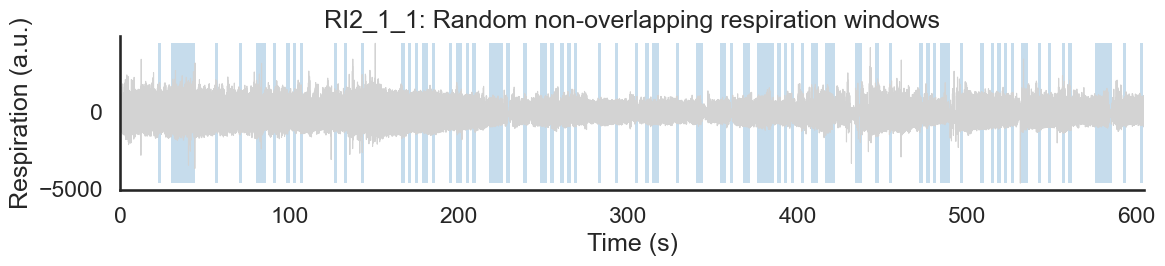

In [42]:
trial_key = "RI2_1_1"
resp_path = all_resp_paths[trial_key]

signal, time, fs, meta = load_clean_resp_signal(resp_path)

rates, windows = sample_random_resp_windows(
    signal,
    time,
    fs,
    window_sec=2.0,
    n_samples=100,      # use fewer for visualization
    random_state=42,
    return_windows=True
)

plot_sampled_windows(
    signal,
    time,
    windows,
    title=f"{trial_key}: Random non-overlapping respiration windows"
)


In [43]:
windows_sorted = sorted(windows, key=lambda x: x[0])


In [44]:
def plot_sampled_windows_zoom(signal, time, windows, t_start, t_end, title):
    fig, ax = plt.subplots(figsize=(10, 3))

    # Mask signal to zoom region
    mask = (time >= t_start) & (time <= t_end)
    ax.plot(time[mask], signal[mask], color="lightgray", lw=1)

    # Overlay windows
    for (w_start, w_stop) in windows:
        if w_stop < t_start or w_start > t_end:
            continue
        ax.axvspan(
            max(w_start, t_start),
            min(w_stop, t_end),
            color="tab:blue",
            alpha=0.35
        )

    ax.set_xlim(t_start, t_end)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Respiration (a.u.)")
    ax.set_title(title)

    sns.despine()
    plt.tight_layout()
    plt.show()


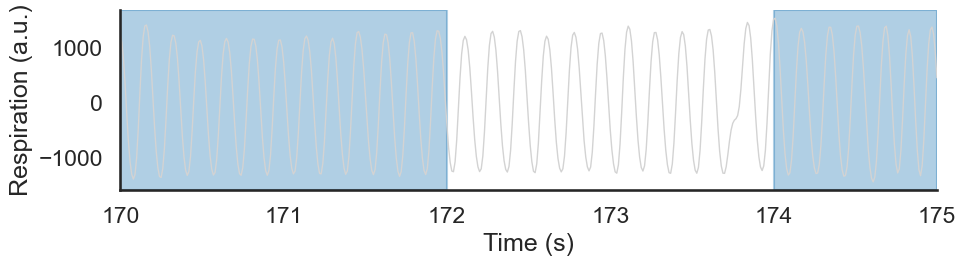

In [45]:
plot_sampled_windows_zoom(
    signal,
    time,
    windows_sorted,
    t_start=170,
    t_end=175,
    title=''
)


In [46]:
rows = []

for trial, h5_path in all_resp_paths.items():
    signal, time, fs, meta = load_clean_resp_signal(h5_path)
    if signal is None:
        continue

    rates = sample_random_resp_windows(
        signal,
        time,
        fs,
        window_sec=2.0,
        n_samples=100,
        random_state=42
    )

    # metadata
    condition = trial.split("_")[0]
    subject = "_".join(trial.split("_")[1:3])
    rank = rank_map.get(subject, np.nan)

    for r in rates:
        rows.append({
            "Trial": trial,
            "Subject": subject,
            "Condition": condition,
            "Rank": rank,
            "RespRate": r
        })

resp_sample_df = pd.DataFrame(rows)
print(resp_sample_df.shape)
resp_sample_df.head()


(3900, 5)


,Trial,Subject,Condition,Rank,RespRate
0,RI1_3_6,3_6,RI1,Dominant,6.925523
1,RI1_3_6,3_6,RI1,Dominant,6.624814
2,RI1_3_6,3_6,RI1,Dominant,8.002083
3,RI1_3_6,3_6,RI1,Dominant,8.237513
4,RI1_3_6,3_6,RI1,Dominant,8.176525


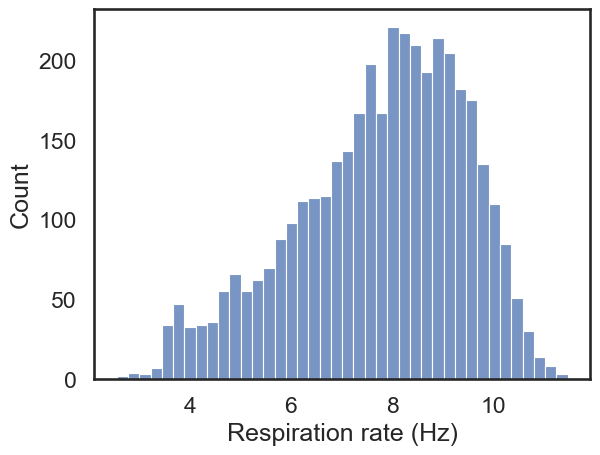

In [47]:
# how many samples per trial?
resp_sample_df.groupby("Trial").size().describe()

# rate distribution
sns.histplot(resp_sample_df["RespRate"], bins=40)
plt.xlabel("Respiration rate (Hz)")
plt.show()


In [48]:
df_val = resp_sample_df.query("Condition in ['RI1', 'RI2']").dropna()

X = df_val[["RespRate"]].to_numpy()
y = (df_val["Condition"] == "RI1").astype(int).to_numpy()
groups = df_val["Subject"].to_numpy()

cv = GroupKFold(n_splits=len(np.unique(groups)))
aucs = []

for tr, te in cv.split(X, y, groups):
    if len(np.unique(y[te])) < 2:
        continue

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=0.1,
            solver="liblinear"
        ))
    ])

    model.fit(X[tr], y[tr])
    y_pred = model.predict_proba(X[te])[:, 1]
    aucs.append(roc_auc_score(y[te], y_pred))

print(f"Resp-only valence AUC: {np.mean(aucs):.2f}")


Resp-only valence AUC: 0.83


In [49]:
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd

df_val = resp_sample_df.query("Condition in ['RI1', 'RI2']").dropna()

X = df_val[["RespRate"]].to_numpy()
y_valence = (df_val["Condition"] == "RI1").astype(int).to_numpy()
groups = df_val["Subject"].to_numpy()

cv = GroupKFold(n_splits=len(np.unique(groups)))

aucs_val = []
valence_coefs = []

for tr, te in cv.split(X, y_valence, groups):

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=0.1,
            solver="liblinear"
        ))
    ])

    # --- ALWAYS fit ---
    model.fit(X[tr], y_valence[tr])

    # --- ALWAYS store weights ---
    valence_coefs.append(
        model.named_steps["clf"].coef_.ravel()
    )

    # --- ONLY compute AUC if test fold has both classes ---
    if len(np.unique(y_valence[te])) >= 2:
        y_pred = model.predict_proba(X[te])[:, 1]
        aucs_val.append(roc_auc_score(y_valence[te], y_pred))

# convert to array AFTER loop
valence_coefs = np.asarray(valence_coefs)

print(f"Resp-only valence AUC: {np.mean(aucs_val):.2f}")
print(f"Stored weight folds: {valence_coefs.shape[0]}")


Resp-only valence AUC: 0.83
Stored weight folds: 8


In [50]:
print("=== FULL DATA CHECK ===")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique y values:", np.unique(y, return_counts=True))
print("Unique subjects:", np.unique(groups))
print("Number of subjects:", len(np.unique(groups)))
print()


=== FULL DATA CHECK ===
X shape: (1600, 1)
y shape: (1600,)
Unique y values: (array([0, 1]), array([800, 800], dtype=int64))
Unique subjects: ['1_1' '1_2' '2_3' '2_4' '3_5' '3_6' '4_7' '4_8']
Number of subjects: 8



Resp-only Valence AUC: 0.83 ± 0.03


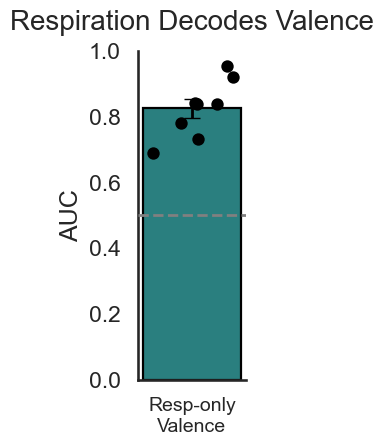

In [51]:
# --- Summary stats ---
auc_mean = np.mean(aucs)
auc_sem  = np.std(aucs) / np.sqrt(len(aucs))

print(f"Resp-only Valence AUC: {auc_mean:.2f} ± {auc_sem:.2f}")

# --- Plot ---
sns.set(style="white", context="talk")
plt.figure(figsize=(2.4, 4.8))

# Mean bar
plt.bar(
    [0],
    [auc_mean],
    width=0.25,
    color="#2A7F7F",   # same valence color you’ve been using
    edgecolor="black",
    linewidth=1.6,
    zorder=1
)

# Error bar (SEM)
plt.errorbar(
    0,
    auc_mean,
    yerr=auc_sem,
    fmt="none",
    ecolor="black",
    capsize=6,
    lw=2,
    zorder=3
)

# Per-fold dots (LOSO folds)
jitter = np.random.normal(0, 0.05, size=len(aucs))
plt.scatter(
    jitter,
    aucs,
    color="black",
    s=55,
    zorder=4
)

# Chance line
plt.axhline(0.5, ls="--", color="gray", lw=2, zorder=3)

# Axes
plt.xticks([0], ["Resp-only\nValence"], fontsize=14)
plt.ylabel("AUC", fontsize=18)
plt.ylim(0, 1)
plt.title("Respiration Decodes Valence", fontsize=20, pad=15)

sns.despine()
plt.tight_layout()
plt.show()


In [52]:
# -------------------------------
# Train on VALENCE windows
# -------------------------------
valence_df = resp_sample_df.query("Condition in ['RI1','RI2']").copy()

X_val = valence_df[["RespRate"]].to_numpy()
y_val = (valence_df["Condition"] == "RI1").astype(int).to_numpy()

valence_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        C=0.1,
        solver="liblinear",
        class_weight="balanced"
    ))
])

valence_model.fit(X_val, y_val)

print("Valence model trained")


Valence model trained


In [53]:
# -------------------------------
# Apply to RANK windows
# -------------------------------
rank_df = resp_sample_df.query(
    "Condition in ['CM'] and Rank.notnull()"
).copy()

X_rank = rank_df[["RespRate"]].to_numpy()
y_rank = (rank_df["Rank"] == "Dominant").astype(int).to_numpy()

# Predict valence score on rank data
y_pred_rank = valence_model.predict_proba(X_rank)[:, 1]

auc_transfer = roc_auc_score(y_rank, y_pred_rank)

print(f"Valence → Rank transfer AUC: {auc_transfer:.3f}")


Valence → Rank transfer AUC: 0.367


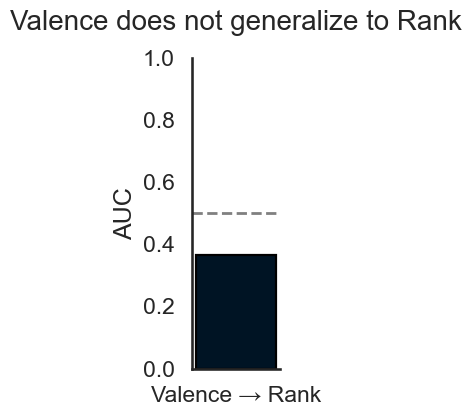

In [54]:
plt.figure(figsize=(2.2, 4.5))

# Mean bar
plt.bar(
    ["Valence → Rank"],
    [auc_transfer],
    width=0.35,
    color="#001424",  # distinct color for transfer
    edgecolor="black",
    linewidth=1.6
)

# Chance line
plt.axhline(0.5, ls="--", color="gray", lw=2)

plt.ylim(0, 1)
plt.ylabel("AUC", fontsize=18)
plt.title("Valence does not generalize to Rank", pad=20, fontsize=20)

sns.despine()
plt.tight_layout()
plt.show()


In [55]:
rank_df = resp_sample_df.query(
    "Condition in ['CM'] and Rank.notnull()"
).copy()

X = rank_df[["RespRate"]].to_numpy()
y = (rank_df["Rank"] == "Dominant").astype(int).to_numpy()
subjects = rank_df["Subject"].to_numpy()


In [56]:
rank_df

,Trial,Subject,Condition,Rank,RespRate
2300,CM_1_1_d1_2,1_1,CM,Subordinate,7.119611
2301,CM_1_1_d1_2,1_1,CM,Subordinate,8.208945
2302,CM_1_1_d1_2,1_1,CM,Subordinate,7.849673
2303,CM_1_1_d1_2,1_1,CM,Subordinate,7.409129
2304,CM_1_1_d1_2,1_1,CM,Subordinate,7.059031
...,...,...,...,...,...
3095,CM_4_8_sub4_7,4_8,CM,Dominant,6.400121
3096,CM_4_8_sub4_7,4_8,CM,Dominant,10.622766
3097,CM_4_8_sub4_7,4_8,CM,Dominant,5.496791
3098,CM_4_8_sub4_7,4_8,CM,Dominant,9.443973


In [57]:
pair_groups = [
    ["1_1", "1_2"],
    ["2_3", "2_4"],
    ["3_5", "3_6"],
    ["4_7", "4_8"],
]


In [58]:
aucs = []
pair_labels = []

for pair in pair_groups:
    test_mask = np.isin(subjects, pair)
    train_mask = ~test_mask

    # skip invalid folds
    if len(np.unique(y[test_mask])) < 2:
        continue

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=0.1,
            solver="liblinear"
        ))
    ])

    model.fit(X[train_mask], y[train_mask])
    y_pred = model.predict_proba(X[test_mask])[:, 1]

    auc = roc_auc_score(y[test_mask], y_pred)
    aucs.append(auc)
    pair_labels.append(f"{pair[0]} vs {pair[1]}")


In [59]:
auc_mean = np.mean(aucs)
auc_sem = np.std(aucs) / np.sqrt(len(aucs))

print(f"Rank decoding AUC: {auc_mean:.2f} ± {auc_sem:.2f}")


Rank decoding AUC: 0.63 ± 0.09


In [60]:
aucs = []
pair_labels = []
rank_coefs = []

df_rank = resp_sample_df.query(
    "Condition == 'CM' and Rank.notnull()"
).dropna()

X = df_rank[["RespRate"]].to_numpy()
y = (df_rank["Rank"] == "Dominant").astype(int).to_numpy()
subjects = df_rank["Subject"].to_numpy()

for pair in pair_groups:
    test_mask = np.isin(subjects, pair)
    train_mask = ~test_mask

    # skip invalid folds
    if len(np.unique(y[test_mask])) < 2:
        continue

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=0.1,
            solver="liblinear"
        ))
    ])

    model.fit(X[train_mask], y[train_mask])

    # --- performance ---
    y_pred = model.predict_proba(X[test_mask])[:, 1]
    auc = roc_auc_score(y[test_mask], y_pred)
    aucs.append(auc)
    pair_labels.append(f"{pair[0]} vs {pair[1]}")

    # --- STORE WEIGHT ---
    rank_coefs.append(
        model.named_steps["clf"].coef_.ravel()
    )

rank_coefs = np.vstack(rank_coefs)

print(f"Rank AUC: {np.mean(aucs):.2f}")


Rank AUC: 0.63


In [61]:
print("Valence AUC folds:", len(aucs))
print("Valence coef folds:", len(valence_coefs))


Valence AUC folds: 4
Valence coef folds: 8


In [62]:
valence_coefs = np.asarray(valence_coefs)
rank_coefs    = np.asarray(rank_coefs)


In [63]:
val_mean = valence_coefs.mean()
val_sem  = valence_coefs.std() / np.sqrt(len(valence_coefs))

rank_mean = rank_coefs.mean()
rank_sem  = rank_coefs.std() / np.sqrt(len(rank_coefs))


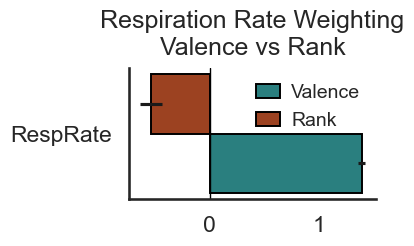

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

labels = ["RespRate"]

y = np.arange(len(labels))
height = 0.35

plt.figure(figsize=(4.2, 2.8))

# Valence
plt.barh(
    y - height/2,
    [val_mean],
    xerr=[val_sem],
    height=height,
    color="#2A7F7F",
    edgecolor="black",
    linewidth=1.4,
    label="Valence"
)

# Rank
plt.barh(
    y + height/2,
    [rank_mean],
    xerr=[rank_sem],
    height=height,
    color="#9C4221",
    edgecolor="black",
    linewidth=1.4,
    label="Rank"
)

plt.axvline(0, color="black", lw=1)
plt.yticks(y, labels)
plt.xlabel('')
plt.title("Respiration Rate Weighting\nValence vs Rank", pad=10)
#plt.legend(frameon=False)
plt.legend(
    loc="upper right",
    frameon=False,
    fontsize=14,
    handlelength=1.2,
    handletextpad=0.6,
    borderaxespad=0.4
)


sns.despine()
plt.tight_layout()
plt.show()


In [65]:
print("Valence labels:", np.unique(y_valence))
print("Rank labels:", np.unique(y_rank))


Valence labels: [0 1]
Rank labels: [0 1]


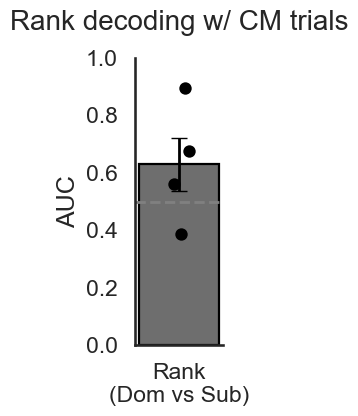

In [66]:
plt.figure(figsize=(2.2, 4.5))

# Mean bar
plt.bar(
    ["Rank\n(Dom vs Sub)"],
    [auc_mean],
    width=0.25,
    color="#6E6E6E",
    edgecolor="black",
    linewidth=1.6
)

# Error bar
plt.errorbar(
    x=[0],
    y=[auc_mean],
    yerr=[auc_sem],
    fmt="none",
    ecolor="black",
    capsize=6,
    lw=2
)

#Per-fold dots (LOSO folds)
jitter = np.random.normal(0, 0.02, size=len(aucs))
plt.scatter(
    jitter,
    aucs,
    color="black",
    s=55,
    zorder=4
)
# Chance
plt.axhline(0.5, ls="--", color="gray", lw=2)

plt.ylim(0, 1)
plt.ylabel("AUC", fontsize=18)
plt.title("Rank decoding w/ CM trials", pad=20, fontsize=20)

sns.despine()
plt.tight_layout()
plt.show()


In [67]:
pair_results = []

for pair in pair_groups:
    test_mask = np.isin(subjects, pair)
    train_mask = ~test_mask

    if len(np.unique(y[test_mask])) < 2:
        print(f"Skipping {pair} (single class)")
        continue

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(C=0.1, solver="liblinear"))
    ])

    model.fit(X[train_mask], y[train_mask])
    y_pred = model.predict_proba(X[test_mask])[:, 1]

    auc = roc_auc_score(y[test_mask], y_pred)
    pair_results.append((pair, auc))

    print(f"Pair {pair}: AUC = {auc:.2f}")


IndexError: boolean index did not match indexed array along dimension 0; dimension is 1 but corresponding boolean dimension is 800

In [68]:
rank_df

,Trial,Subject,Condition,Rank,RespRate
2300,CM_1_1_d1_2,1_1,CM,Subordinate,7.119611
2301,CM_1_1_d1_2,1_1,CM,Subordinate,8.208945
2302,CM_1_1_d1_2,1_1,CM,Subordinate,7.849673
2303,CM_1_1_d1_2,1_1,CM,Subordinate,7.409129
2304,CM_1_1_d1_2,1_1,CM,Subordinate,7.059031
...,...,...,...,...,...
3095,CM_4_8_sub4_7,4_8,CM,Dominant,6.400121
3096,CM_4_8_sub4_7,4_8,CM,Dominant,10.622766
3097,CM_4_8_sub4_7,4_8,CM,Dominant,5.496791
3098,CM_4_8_sub4_7,4_8,CM,Dominant,9.443973


C:\Users\sjs93\AppData\Local\Temp\ipykernel_38272\620136213.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


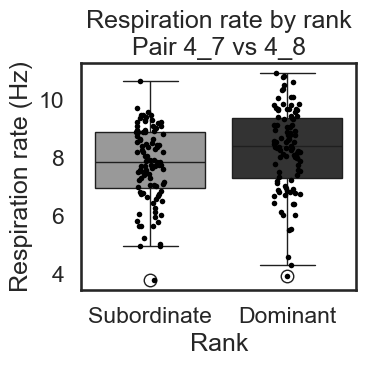

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

pair_df = rank_df.query("Subject in @bad_pair")

plt.figure(figsize=(4,4))
sns.boxplot(
    data=pair_df,
    x="Rank",
    y="RespRate",
    palette=["#999999", "#333333"]
)
sns.stripplot(
    data=pair_df,
    x="Rank",
    y="RespRate",
    color="black",
    size=4,
    jitter=True
)

plt.title(f"Respiration rate by rank\nPair {bad_pair[0]} vs {bad_pair[1]}")
plt.ylabel("Respiration rate (Hz)")
plt.tight_layout()
plt.show()


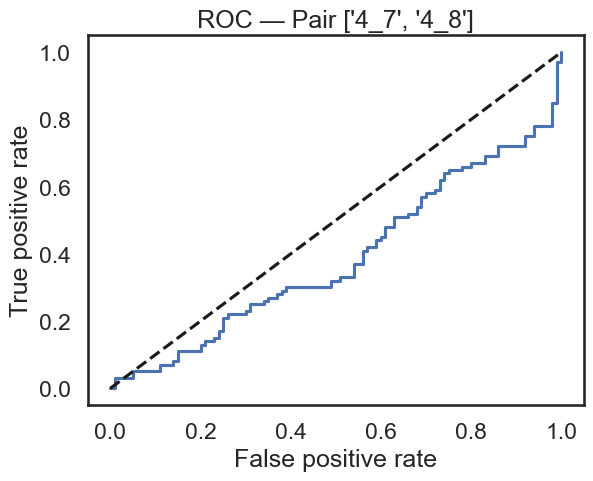

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y[test_mask], y_pred)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title(f"ROC — Pair {bad_pair}")
plt.show()


In [ ]:
# ----------------------------------
# CM-only rank dataset
# ----------------------------------
rank_df = resp_sample_df.query(
    "Condition == 'CM' and Rank.notnull()"
).copy()

X = rank_df[["RespRate"]].to_numpy()
y = (rank_df["Rank"] == "Dominant").astype(int).to_numpy()
#groups = rank_df["Subject"].to_numpy()   #  FIX IS HERE

print("Shapes:", X.shape, y.shape, groups.shape)

# ----------------------------------
# 5-fold GROUP cross-validation
# ----------------------------------
cv = GroupKFold(n_splits=5)
aucs = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups), 1):

    # Require both classes in test fold
    if len(np.unique(y[test_idx])) < 2:
        print(f" Skipping fold {fold} (single class in test)")
        continue

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=0.1,
            solver="liblinear",
            class_weight="balanced"
        ))
    ])

    model.fit(X[train_idx], y[train_idx])
    y_pred = model.predict_proba(X[test_idx])[:, 1]

    auc = roc_auc_score(y[test_idx], y_pred)
    aucs.append(auc)

    print(f"Fold {fold}: AUC = {auc:.2f}")

print(f"\nRank decoding (CM only): {np.mean(aucs):.2f} ± {np.std(aucs)/np.sqrt(len(aucs)):.2f}")



Shapes: (800, 1) (800,) (800,)
Fold 1: AUC = 0.50
Fold 2: AUC = 0.63
Fold 3: AUC = 0.96
 Skipping fold 4 (single class in test)
 Skipping fold 5 (single class in test)

Rank decoding (CM only): 0.70 ± 0.11


Fold 1: AUC = 0.63
Fold 2: AUC = 0.65
Fold 3: AUC = 0.68
Fold 4: AUC = 0.59
Fold 5: AUC = 0.64
Fold 6: AUC = 0.56
Fold 7: AUC = 0.60
Fold 8: AUC = 0.59
Fold 9: AUC = 0.74
Fold 10: AUC = 0.63

Rank decoding (CM only, forced window-level CV): 0.63 ± 0.02
Fold 10: Train n=720, Test n=80, Train classes=[0 1], Test classes=[0 1]


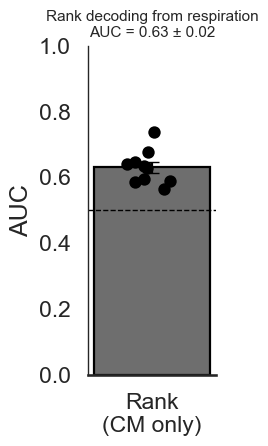

X shape: (800, 1)
y shape: (800,)
Features used: ['RespRate']
Label distribution: (array([0, 1]), array([400, 400], dtype=int64))


In [ ]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

aucs = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=0.1,
            solver="liblinear",
            class_weight="balanced"
        ))
    ])

    model.fit(X[train_idx], y[train_idx])
    y_pred = model.predict_proba(X[test_idx])[:, 1]

    auc = roc_auc_score(y[test_idx], y_pred)
    aucs.append(auc)

    print(f"Fold {fold}: AUC = {auc:.2f}")

print(
    f"\nRank decoding (CM only, forced window-level CV): "
    f"{np.mean(aucs):.2f} ± {np.std(aucs)/np.sqrt(len(aucs)):.2f}"
)

print(
    f"Fold {fold}: "
    f"Train n={len(train_idx)}, "
    f"Test n={len(test_idx)}, "
    f"Train classes={np.unique(y[train_idx])}, "
    f"Test classes={np.unique(y[test_idx])}"
)

# ----------------------------------
# Plot AUCs
# ----------------------------------
aucs = np.array(aucs)
auc_mean = aucs.mean()
auc_sem  = aucs.std(ddof=1) / np.sqrt(len(aucs))

# jitter for fold dots
jitter = np.random.normal(0, 0.04, size=len(aucs))

plt.figure(figsize=(2.6, 4.8))

# Mean bar
plt.bar(
    [0],
    [auc_mean],
    width=0.25,
    color="#6E6E6E",
    edgecolor="black",
    linewidth=1.6,
    zorder=1
)

# Error bar (SEM)
plt.errorbar(
    x=[0],
    y=[auc_mean],
    yerr=[auc_sem],
    fmt="none",
    ecolor="black",
    capsize=5,
    linewidth=1.6,
    zorder=3
)

# Per-fold dots
plt.scatter(
    jitter,
    aucs,
    color="black",
    s=55,
    zorder=4
)

# Chance line
plt.axhline(0.5, linestyle="--", color="black", linewidth=1)

# Formatting
plt.ylim(0, 1)
plt.xticks([0], ["Rank\n(CM only)"])
plt.ylabel("AUC")

plt.title(
    "Rank decoding from respiration\n"
    f"AUC = {auc_mean:.2f} ± {auc_sem:.2f}",
    fontsize=11
)
#remove top/right spines
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
plt.tight_layout()
plt.show()


print("X shape:", X.shape)
print("y shape:", y.shape)
print("Features used:", rank_df[["RespRate"]].columns.tolist())
print("Label distribution:", np.unique(y, return_counts=True))



In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
import numpy as np

cv = StratifiedKFold(n_splits=8, shuffle=True, random_state=42)

aucs = []
accs = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=0.1,
            solver="liblinear",
            class_weight="balanced"
        ))
    ])

    # Train
    model.fit(X[train_idx], y[train_idx])

    # Probabilities (for ROC AUC)
    y_prob = model.predict_proba(X[test_idx])[:, 1]

    # Hard predictions at 0.5 (for accuracy)
    y_hat = (y_prob >= 0.5).astype(int)

    # Metrics
    auc = roc_auc_score(y[test_idx], y_prob)
    acc = accuracy_score(y[test_idx], y_hat)

    aucs.append(auc)
    accs.append(acc)

    print(f"Fold {fold}: AUC = {auc:.2f}, Accuracy = {acc:.2f}")

print("\nSummary:")
print(f"ROC AUC: {np.mean(aucs):.2f} ± {np.std(aucs)/np.sqrt(len(aucs)):.2f}")
print(f"Accuracy: {np.mean(accs):.2f} ± {np.std(accs)/np.sqrt(len(accs)):.2f}")


Fold 1: AUC = 0.64, Accuracy = 0.63
Fold 2: AUC = 0.66, Accuracy = 0.63
Fold 3: AUC = 0.64, Accuracy = 0.61
Fold 4: AUC = 0.61, Accuracy = 0.57
Fold 5: AUC = 0.59, Accuracy = 0.60
Fold 6: AUC = 0.61, Accuracy = 0.59
Fold 7: AUC = 0.68, Accuracy = 0.63
Fold 8: AUC = 0.64, Accuracy = 0.60

Summary:
ROC AUC: 0.63 ± 0.01
Accuracy: 0.61 ± 0.01


In [ ]:
train_idx

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  12,  13,
        14,  15,  16,  18,  20,  21,  23,  24,  26,  27,  28,  29,  31,
        32,  33,  34,  35,  36,  37,  38,  39,  41,  42,  43,  44,  46,
        47,  48,  49,  50,  51,  52,  53,  55,  56,  57,  58,  59,  60,
        61,  62,  63,  64,  65,  66,  67,  69,  70,  71,  72,  73,  75,
        76,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,
        90,  91,  92,  93,  94,  95,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 119,
       120, 121, 122, 123, 124, 125, 126, 128, 129, 131, 132, 133, 134,
       136, 137, 138, 139, 140, 141, 142, 143, 144, 146, 147, 148, 149,
       151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163,
       164, 165, 166, 167, 168, 169, 170, 174, 175, 176, 177, 179, 180,
       181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193,
       194, 195, 196, 197, 198, 200, 201, 202, 203, 204, 205, 20

In [ ]:
test_idx

array([ 11,  17,  19,  22,  25,  30,  40,  45,  54,  68,  74,  77,  96,
        97, 117, 118, 127, 130, 135, 145, 150, 171, 172, 173, 178, 199,
       211, 213, 249, 259, 260, 266, 292, 330, 331, 365, 367, 370, 373,
       384, 388, 392, 416, 418, 420, 427, 437, 438, 440, 446, 455, 501,
       512, 513, 520, 522, 534, 543, 555, 573, 585, 590, 602, 613, 622,
       624, 625, 655, 658, 665, 687, 692, 718, 722, 738, 744, 764, 782,
       790, 791])

5 sec long random signal 

In [ ]:
rows = []

for trial, h5_path in all_resp_paths.items():
    signal, time, fs, meta = load_clean_resp_signal(h5_path)
    if signal is None:
        continue

    # --- determine how many 5-s windows are possible ---
    window_sec = 5.0
    window_len = int(window_sec * fs)
    total_len = len(signal)

    max_windows = total_len // window_len
    if max_windows < 1:
        print(f"Skipping {trial}: <1 usable 5s window")
        continue

    n_samples_use = min(100, max_windows)

    # --- sample respiration windows ---
    rates = sample_random_resp_windows(
        signal,
        time,
        fs,
        window_sec=window_sec,
        n_samples=n_samples_use,
        random_state=42
    )

    # --- metadata ---
    condition = trial.split("_")[0]
    subject = "_".join(trial.split("_")[1:3])
    rank = rank_map.get(subject, np.nan)

    for r in rates:
        rows.append({
            "Trial": trial,
            "Subject": subject,
            "Condition": condition,
            "Rank": rank,
            "RespRate": r,
            "WindowSec": 5.0
        })

resp_sample_df_5sec = pd.DataFrame(rows)
print(resp_sample_df_5sec.shape)
resp_sample_df_5sec.head()


(3842, 6)


,Trial,Subject,Condition,Rank,RespRate,WindowSec
0,RI1_3_6,3_6,RI1,Dominant,7.215719,5.0
1,RI1_3_6,3_6,RI1,Dominant,8.312670,5.0
2,RI1_3_6,3_6,RI1,Dominant,7.281338,5.0
3,RI1_3_6,3_6,RI1,Dominant,9.803683,5.0
4,RI1_3_6,3_6,RI1,Dominant,7.025499,5.0


In [ ]:
windows_sorted = sorted(windows, key=lambda x: x[0])


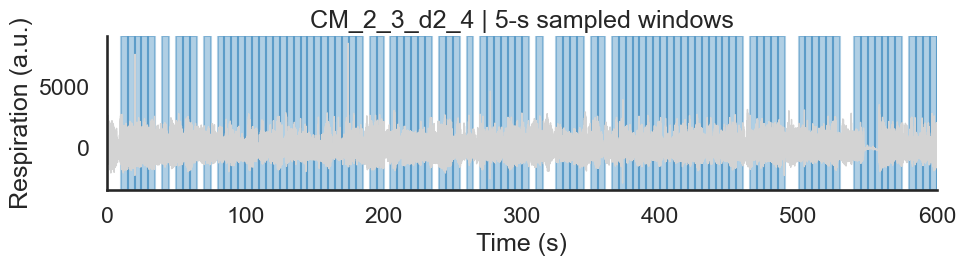

In [ ]:
plot_sampled_windows_zoom(
    signal,
    time,
    windows_sorted,
    t_start=0,
    t_end=600,
    title=f"{trial} | 5-s sampled windows"
)


In [ ]:
df_val = resp_sample_df_5sec.query("Condition in ['RI1', 'RI2']").dropna()

X = df_val[["RespRate"]].to_numpy()
y = (df_val["Condition"] == "RI1").astype(int).to_numpy()
groups = df_val["Subject"].to_numpy()

cv = GroupKFold(n_splits=len(np.unique(groups)))
aucs = []

for tr, te in cv.split(X, y, groups):
    if len(np.unique(y[te])) < 2:
        continue

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=0.1,
            solver="liblinear"
        ))
    ])

    model.fit(X[tr], y[tr])
    y_pred = model.predict_proba(X[te])[:, 1]
    aucs.append(roc_auc_score(y[te], y_pred))

print(f"Resp-only valence AUC: {np.mean(aucs):.2f}")

Resp-only valence AUC: 0.85


In [ ]:
rank_df_5s = resp_sample_df_5sec.query(
    "Condition in ['CM','RI1','RI2'] and Rank.notnull()"
).copy()


In [ ]:
X = rank_df_5s[["RespRate"]].to_numpy()
y = (rank_df_5s["Rank"] == "Dominant").astype(int).to_numpy()
subjects = rank_df_5s["Subject"].to_numpy()


In [ ]:
aucs_5s = []
pair_labels_5s = []

for pair in pair_groups:
    test_mask = np.isin(subjects, pair)
    train_mask = ~test_mask

    if len(np.unique(y[test_mask])) < 2:
        continue

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=0.1,
            solver="liblinear",
            class_weight="balanced"
        ))
    ])

    model.fit(X[train_mask], y[train_mask])
    y_pred = model.predict_proba(X[test_mask])[:, 1]

    auc = roc_auc_score(y[test_mask], y_pred)
    aucs_5s.append(auc)
    pair_labels_5s.append(f"{pair[0]} vs {pair[1]}")


In [ ]:
mean_auc_5s = np.mean(aucs_5s)
sem_auc_5s  = np.std(aucs_5s) / np.sqrt(len(aucs_5s))

print(f"Rank decoding (5-s bouts): {mean_auc_5s:.3f} ± {sem_auc_5s:.3f}")


Rank decoding (5-s bouts): 0.563 ± 0.032


PLOTTING only no fitting models 

C:\Users\sjs93\AppData\Local\Temp\ipykernel_48544\1726558519.py:28: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\sjs93\AppData\Local\Temp\ipykernel_48544\1726558519.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


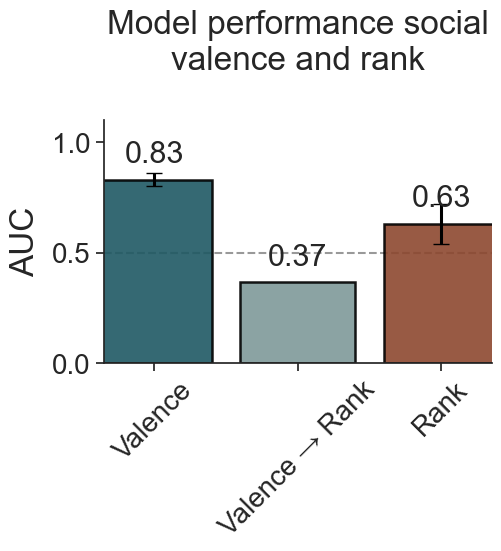

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# --- Data ---
auc_data = pd.DataFrame({
    "Model": ["Valence", "Valence → Rank", "Rank"],
    "AUC": [0.83, 0.367, 0.63],
    "SEM": [0.03, np.nan, 0.09]
})

# --- Colors (Padilla-style complementary tones) ---
lab_palette = {
    "Valence": "#15616F",     # deep teal
    "Valence → Rank": "#7A9E9F",   # muted blue-gray
    "Rank": "#9C4221"         # rust brown
}

# --- Poster style ---
sns.set(style="ticks", font_scale=1.9)
fig, ax = plt.subplots(figsize=(5.5, 6))
fig.patch.set_alpha(0.0)      # transparent background
ax.set_facecolor("none")

# --- Bar plot ---
sns.barplot(
    data=auc_data,
    x="Model", y="AUC",
    palette=lab_palette,
    width=0.8, edgecolor="black", linewidth=1.8,
    ci=None, alpha=0.9, ax=ax
)

# --- Error bars ---
for i, row in auc_data.iterrows():
    ax.errorbar(
        i, row["AUC"], yerr=row["SEM"],
        fmt="none", ecolor="black", elinewidth=2.2, capsize=6
    )

# --- Annotate values ---
for i, row in auc_data.iterrows():
    ax.text(
        i, row["AUC"] + 0.05, f"{row['AUC']:.2f}",
        ha="center", va="bottom",
        fontsize=22, weight="normal"
    )

# --- Chance line ---
ax.axhline(
    0.5,
    ls="--",
    color="black",
    lw=1.5,
    alpha=0.4,
    zorder=0
)


# --- Axes and layout ---
ax.set_ylim(0, 1.1)
ax.set_xlim(-0.35, 2.35)
ax.set_ylabel("AUC", fontsize=24, labelpad=8)
ax.set_xlabel("")
ax.set_title("Model performance social valence and rank",
             fontsize=24, pad=40, weight="normal", wrap=True)
ax.tick_params(axis="x", labelrotation=45, labelsize=20)
ax.tick_params(axis="y", labelsize=20)
sns.despine()
plt.tight_layout()
plt.show()

C:\Users\sjs93\AppData\Local\Temp\ipykernel_48544\2192533025.py:27: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\sjs93\AppData\Local\Temp\ipykernel_48544\2192533025.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


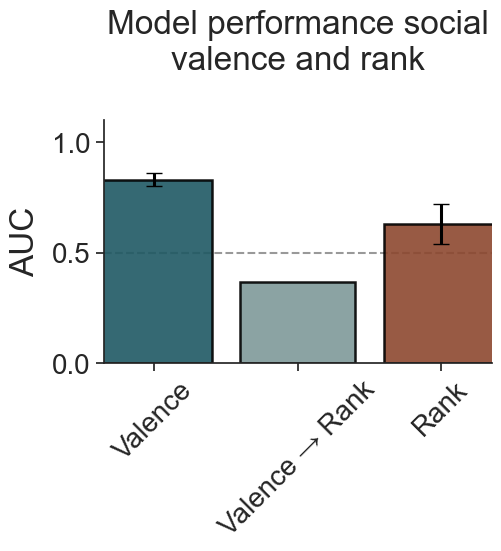

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Data ---
auc_data = pd.DataFrame({
    "Model": ["Valence", "Valence → Rank", "Rank"],
    "AUC": [0.83, 0.367, 0.63],
    "SEM": [0.03, np.nan, 0.09]
})

# --- Colors (Padilla-style complementary tones) ---
lab_palette = {
    "Valence": "#15616F",          # deep teal
    "Valence → Rank": "#7A9E9F",   # muted blue-gray
    "Rank": "#9C4221"              # rust brown
}

# --- Poster style ---
sns.set(style="ticks", font_scale=1.9)
fig, ax = plt.subplots(figsize=(5.5, 6))
fig.patch.set_alpha(0.0)
ax.set_facecolor("none")

# --- Bar plot ---
sns.barplot(
    data=auc_data,
    x="Model", y="AUC",
    palette=lab_palette,
    width=0.8, edgecolor="black", linewidth=1.8,
    ci=None, alpha=0.9, ax=ax
)

# --- Error bars ---
for i, row in auc_data.iterrows():
    ax.errorbar(
        i, row["AUC"], yerr=row["SEM"],
        fmt="none", ecolor="black",
        elinewidth=2.2, capsize=6
    )

# --- Chance line ---
ax.axhline(
    0.5,
    ls="--",
    color="black",
    lw=1.5,
    alpha=0.4,
    zorder=0
)

# --- Axes and layout ---
ax.set_ylim(0, 1.1)
ax.set_xlim(-0.35, 2.35)
ax.set_ylabel("AUC", fontsize=24, labelpad=8)
ax.set_xlabel("")
ax.set_title(
    "Model performance social valence and rank",
    fontsize=24, pad=40, weight="normal", wrap=True
)
ax.tick_params(axis="x", labelrotation=45, labelsize=20)
ax.tick_params(axis="y", labelsize=20)

sns.despine()
plt.tight_layout()
plt.show()
